<h2 style="color:#8B004F; font-weight:bold; text-align:center;">
Implementación computacional del método de rigidez para el análisis matricial de una cercha plana.                          
</h2>

<h2 style="color:#8B004F; font-weight:bold; text-align:center;">
   Computational Implementation of the Stiffness Method for Matrix Analysis of a Plane Truss
</h2>

   
Autor: Anuar González A. 
Versión: 1.0.0  
Fecha: 2026-05-05  
DOI: 10.5281/zenodo.20042213

Cómo citar:

González, A. (2026). Computational Implementation of the Stiffness Method for Matrix Analysis of a Plane Truss, (Versión 1.0.0) [Software] 10.5281/zenodo.20042213



DATOS DE ENTRADA / INPUT DATA




In [128]:


import numpy as np  #numpy = "Numerical Phyton", abreviatura: np 


E  = 200000000;                   # KPA
G = (E/10000000/(2*(1+0.2)))      

A1  =  0.0005 # m2
A2= 0.001

A=np.array([[A1],[A1],[A1],[A1],[A1],[A1],[A2],[A2],[A2],[A2],[A1],[A1],[A1],[A1],[A1],[A1],[A1],[A1],[A1],[A1],[A1]])
A=A

print("Sections elements =",A)



Sections elements = [[5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [1.00e-03]
 [1.00e-03]
 [1.00e-03]
 [1.00e-03]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]
 [5.00e-04]]


### GRADOS DE LIBERTAD NO RESTRINGIDOS (LIBRES)
#### FREE DEGREES OF FREEDOM

In [129]:
GDL_Total=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]
GDL_Total=[x-1 for x in GDL_Total]
print("GDL_Total =",GDL_Total)

GDL_Libres=[3,4,5,6,7,8,9,10,11,12,13,15,16,17,18,19,20,21,22,23,24]
GDL_Libres=[x-1 for x in GDL_Libres]
print("GDL_Libres =", GDL_Libres)

GDL_Total = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
GDL_Libres = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


### DEFINICIÓN DE COORDENADAS DE CADA NODO
#### DEFINITION OF NODE COORDINATES

In [130]:
nod=np.array([ [0, 0], [3, 0] , [6 ,0]  , [9, 0]  ,  [12, 0] , [15, 0]  , [18, 0]  , [3, 3]  , [6, 3]  , [9, 3]  , [12, 3],[15, 3]])  

for i in range (len(nod)): print("Nodo", i+1, ":", nod[i])

print(nod)

Nodo 1 : [0 0]
Nodo 2 : [3 0]
Nodo 3 : [6 0]
Nodo 4 : [9 0]
Nodo 5 : [12  0]
Nodo 6 : [15  0]
Nodo 7 : [18  0]
Nodo 8 : [3 3]
Nodo 9 : [6 3]
Nodo 10 : [9 3]
Nodo 11 : [12  3]
Nodo 12 : [15  3]
[[ 0  0]
 [ 3  0]
 [ 6  0]
 [ 9  0]
 [12  0]
 [15  0]
 [18  0]
 [ 3  3]
 [ 6  3]
 [ 9  3]
 [12  3]
 [15  3]]


### CONECTIVIDAD DE BARRAS:
#### MEMBER CONNECTIVITY:

In [131]:
### DEFINICIÓN DE NUDOS EN LOS EXTREMOS DE LAS BARRAS
#### DEFINITION OF END NODES FOR EACH MEMBER

Barras=np.array([[1,2],[2,3],[3,4],[4,5],[5,6],[6,7],[8,9],[9,10],[10,11],[11,12],[1,8],[2,8],[2,9],[3,9],[3,10],[4,10],[5,10],[5,11],[6,11],[6,12],[7,12]])

for i in range(len(Barras)): print("Barra/Member", i+1, "entre nodos", ":", Barras[i])



Barra/Member 1 entre nodos : [1 2]
Barra/Member 2 entre nodos : [2 3]
Barra/Member 3 entre nodos : [3 4]
Barra/Member 4 entre nodos : [4 5]
Barra/Member 5 entre nodos : [5 6]
Barra/Member 6 entre nodos : [6 7]
Barra/Member 7 entre nodos : [8 9]
Barra/Member 8 entre nodos : [ 9 10]
Barra/Member 9 entre nodos : [10 11]
Barra/Member 10 entre nodos : [11 12]
Barra/Member 11 entre nodos : [1 8]
Barra/Member 12 entre nodos : [2 8]
Barra/Member 13 entre nodos : [2 9]
Barra/Member 14 entre nodos : [3 9]
Barra/Member 15 entre nodos : [ 3 10]
Barra/Member 16 entre nodos : [ 4 10]
Barra/Member 17 entre nodos : [ 5 10]
Barra/Member 18 entre nodos : [ 5 11]
Barra/Member 19 entre nodos : [ 6 11]
Barra/Member 20 entre nodos : [ 6 12]
Barra/Member 21 entre nodos : [ 7 12]


### GRADOS DE LIBERTAD POR CADA NODO:
#### DEGREES OF FREEDOM PER NODE:

In [132]:
GDL=np.array([ [1, 2], [3, 4] , [5 ,6]  , [7, 8]  ,  [9, 10] , [11, 12]  , [13, 14]  , [15, 16]  , [17, 18]  , [19, 20]  , [21, 22],[23, 24]])  

for i in range (len(nod)): print("GDL en nodo", i+1, ":", GDL[i])



GDL en nodo 1 : [1 2]
GDL en nodo 2 : [3 4]
GDL en nodo 3 : [5 6]
GDL en nodo 4 : [7 8]
GDL en nodo 5 : [ 9 10]
GDL en nodo 6 : [11 12]
GDL en nodo 7 : [13 14]
GDL en nodo 8 : [15 16]
GDL en nodo 9 : [17 18]
GDL en nodo 10 : [19 20]
GDL en nodo 11 : [21 22]
GDL en nodo 12 : [23 24]


### GRADOS DE LIBERTAD POR BARRA: “VECTORES COLOCACIÓN”
#### DEGREES OF FREEDOM PER MEMBER: “LOCATION VECTORS”

In [133]:

GDL_Barras=[]
GDL_Barrass=[]
for barras in Barras:
    
  nodo_i,nodo_j=barras
  GDL_i=GDL[nodo_i-1]
  GDL_j=GDL[nodo_j-1]
  GDL_Barras.append(np.concatenate((GDL_i , GDL_j)))
  
GDL_Barras=np.array(GDL_Barras)

for i in range(len(A)):

  print("GDL_de_barra", ":", i+1, GDL_Barras[i])

GDL_de_barra : 1 [1 2 3 4]
GDL_de_barra : 2 [3 4 5 6]
GDL_de_barra : 3 [5 6 7 8]
GDL_de_barra : 4 [ 7  8  9 10]
GDL_de_barra : 5 [ 9 10 11 12]
GDL_de_barra : 6 [11 12 13 14]
GDL_de_barra : 7 [15 16 17 18]
GDL_de_barra : 8 [17 18 19 20]
GDL_de_barra : 9 [19 20 21 22]
GDL_de_barra : 10 [21 22 23 24]
GDL_de_barra : 11 [ 1  2 15 16]
GDL_de_barra : 12 [ 3  4 15 16]
GDL_de_barra : 13 [ 3  4 17 18]
GDL_de_barra : 14 [ 5  6 17 18]
GDL_de_barra : 15 [ 5  6 19 20]
GDL_de_barra : 16 [ 7  8 19 20]
GDL_de_barra : 17 [ 9 10 19 20]
GDL_de_barra : 18 [ 9 10 21 22]
GDL_de_barra : 19 [11 12 21 22]
GDL_de_barra : 20 [11 12 23 24]
GDL_de_barra : 21 [13 14 23 24]


### GENERACIÓN DEL VECTOR DE FUERZAS ACTUANTES
#### GENERATION OF THE APPLIED FORCE VECTOR

In [134]:
### FUERZAS ACTUANTES EN NODOS
#### FORCES ACTING AT NODES

import numpy as np 

PP=np.array([[0],[0],[0],[-10],[0],[-15],[0],[-20],[0],[-15],[0],[-10],[10],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]]) #KN

for i in range (len(PP)):
    print("Nodal force - node:",i+1,":",PP[i])


Nodal force - node: 1 : [0]
Nodal force - node: 2 : [0]
Nodal force - node: 3 : [0]
Nodal force - node: 4 : [-10]
Nodal force - node: 5 : [0]
Nodal force - node: 6 : [-15]
Nodal force - node: 7 : [0]
Nodal force - node: 8 : [-20]
Nodal force - node: 9 : [0]
Nodal force - node: 10 : [-15]
Nodal force - node: 11 : [0]
Nodal force - node: 12 : [-10]
Nodal force - node: 13 : [10]
Nodal force - node: 14 : [0]
Nodal force - node: 15 : [0]
Nodal force - node: 16 : [0]
Nodal force - node: 17 : [0]
Nodal force - node: 18 : [0]
Nodal force - node: 19 : [0]
Nodal force - node: 20 : [0]
Nodal force - node: 21 : [0]
Nodal force - node: 22 : [0]
Nodal force - node: 23 : [0]
Nodal force - node: 24 : [0]


### REPRESENTACIÓN GRÁFICA DEL SISTEMA
#### GRAPHICAL REPRESENTATION OF THE SYSTEM

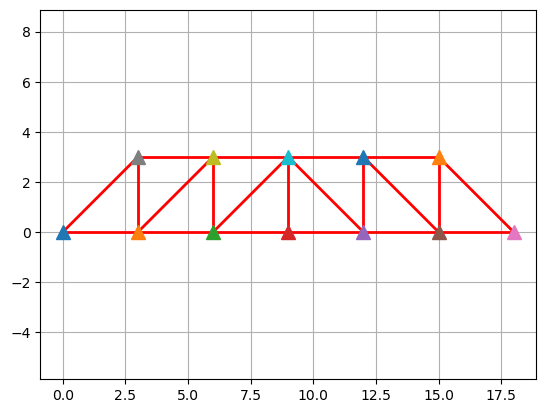

In [135]:
import matplotlib.pyplot as plt

plt.clf()
plt.grid('equal')
plt.axis('equal')

def grafico_de_barras():
    for i,j in Barras:
     x_1,y_1=nod[i-1]
     x_2,y_2=nod[j-1]
     plt.plot([x_1,x_2],[y_1,y_2], 'r-',linewidth=2)

grafico_de_barras()


def grafico_de_nodos():
    for m in range (len(nod)):
     x_n,y_n=nod[m]
     plt.plot(x_n,y_n, '^', markersize=10)

grafico_de_nodos()

### MATRIZ DE TRANSFORMACIÓN DE CADA ELEMENTO
#### TRANSFORMATION MATRIX OF EACH ELEMENT

In [136]:
                                #MATRIZ BETA DE TRANSFORMACIÓN: SENOS Y COSENOS DIRECTORES
    
#Determinación de senos y cosenos para armar las matrices Beta (De transformación) de cada barra

                                
                                # BETA TRANSFORMATION MATRIX: DIRECTION COSINES AND SINES

# Determination of the direction cosines and sines used to assemble the Beta transformation matrix of each member


import cmath
import numpy as np

contador = 0

L=[]
Betas=[]
Beta=np.zeros((4,4))

for m,n in Barras:
    
  x1,y1=nod[m-1]
  print(x1,y1)
  
  x2,y2=nod[n-1]
  print(x2,y2)
  contador +=1
  i=contador
    
  c=(x2-x1)/abs(cmath.sqrt(((x2-x1)**2)+((y2-y1)**2)))
  s=(y2-y1)/abs(cmath.sqrt(((x2-x1)**2)+((y2-y1)**2)))

  Long =[((abs(cmath.sqrt(((x2-x1)**2)+((y2-y1)**2)))))]
  print ("L",i,"=",Long)

  L.append(Long.copy())
  

  Cos_Direc=[c,s] 
    
  print("Cos_Direc_Barra",contador,":",Cos_Direc)
    
  Beta =np.array([[c, s, 0, 0], 
                 [-s, c, 0, 0],
                 [0,  0, c, s],
                 [0,  0, -s, c]])

  print("Beta Barra",i,":",Beta) 

  Betas.append(Beta.copy())

Betas=np.array(Betas)
L=np.array(L)

print("Matriz total de Betas")

print(Betas)
print("Matriz_longitudes / L Members =",L) 

0 0
3 0
L 1 = [3.0]
Cos_Direc_Barra 1 : [1.0, 0.0]
Beta Barra 1 : [[1.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [-0.00e+00 1.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 1.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 -0.00e+00 1.00e+00]]
3 0
6 0
L 2 = [3.0]
Cos_Direc_Barra 2 : [1.0, 0.0]
Beta Barra 2 : [[1.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [-0.00e+00 1.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 1.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 -0.00e+00 1.00e+00]]
6 0
9 0
L 3 = [3.0]
Cos_Direc_Barra 3 : [1.0, 0.0]
Beta Barra 3 : [[1.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [-0.00e+00 1.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 1.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 -0.00e+00 1.00e+00]]
9 0
12 0
L 4 = [3.0]
Cos_Direc_Barra 4 : [1.0, 0.0]
Beta Barra 4 : [[1.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [-0.00e+00 1.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 1.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 -0.00e+00 1.00e+00]]
12 0
15 0
L 5 = [3.0]
Cos_Direc_Barra 5 : [1.0, 0.0]
Beta Barra 5 : [[1.00e+00 0.00e+00 0.00e+00 0.

### MATRICES DE RIGIDEZ DE CADA ELEMENTO, EN COORDENADAS LOCALES Y GLOBALES
#### STIFFNESS MATRICES OF EACH ELEMENT, IN LOCAL AND GLOBAL COORDINATES

In [137]:

import numpy as np

np.set_printoptions(precision=2,     #número de decimales
                    suppress=False,  #permite notacion científica
                    formatter={'float_kind':'{:.2e}'.format},
                     linewidth=10_000, #para no envolver líneas
                     threshold=np.inf #para no ocultar elementos
                     ) 
                    

KK=np.zeros((((len(nod))*2),((len(nod))*2))) 
Kk=np.zeros_like(KK)
KK1=np.zeros_like(KK)
print("GDL max=",GDL_Barras.max())
print("KK.shape=",KK.shape)
print("len(A)",len(A))


print("L_Barras =",(L))



                                    
                                        # MATRICES DE RIGIDEZ EN COORDENADAS LOCALES, DE CADA ELEMENTO:
                                       
                                        # STIFFNESS MATRICES IN LOCAL COORDINATES, FOR EACH ELEMENT:


for z in range(len(GDL_Barras)):
    
  #GDL_Barrasx=np.array(GDL_Barras[z,:])
  GDL_Barrasx=np.array(GDL_Barras[z,:]).copy()
  


  Kl=(E*A[z]/L[z])* np.array([[1, 0, -1, 0], 
                            [0,  0,  0, 0],
                            [-1, 0,  1, 0],
                            [0,  0,  0, 0]])
  print("Kl",z+1,":",Kl) 
  

                                       # MATRICES DE RIGIDEZ EN COORDENADAS GLOBALES, DE CADA ELEMENTO:

                                       # STIFFNESS MATRICES IN GLOBAL COORDINATES, FOR EACH ELEMENT:
    
for z in range(len(GDL_Barras)):
    
 
 GDL_Barrasx=np.array(GDL_Barras[z,:]) 
    
 print("GDL_Barrasx",GDL_Barrasx)

 
 print("BETA",Betas[z])
     
 
 Kl=((Betas[z].T)@((E*(A[z]/L[z]))*np.array([[1, 0, -1, 0], 
                                                            [0,  0,  0, 0],
                                                            [-1, 0,  1, 0],
                                                            [0,  0,  0, 0]]))@(Betas[z]))
     
   
 print("Kl_global_por_barra",":",z+1,Kl)
 
 print(E*A[z]/(L[z]))  

                         # ENSAMBLAJE DE LA MATRIZ DE RIGIDEZ DEL SISTEMA, EN COORDENADAS GLOBALES
                        
                         # ASSEMBLY OF THE SYSTEM STIFFNESS MATRIX IN GLOBAL COORDINATES
    
 for m in range(4):
      
  I=GDL_Barrasx[0]
      
  J=GDL_Barrasx[m]
  print("I",I)
  print("J",J)     
  posx=(I-1)
  posy=(J-1)
  print("posx",posx)
  print("posy",posy)
  KK[posx,posy]+=Kl[0,m] #el -1 se debe a que las GDL inician en 1 y no en 0 que es el lenguaje de Python, para Python el 0 es el 1 en la realidad (en métodos iterativos de paso)
                         # The -1 is used because the DOF numbering starts at 1, whereas Python indexing starts at 0; therefore, index 0 in Python corresponds to DOF 1 in the structural model
                         # during step-by-step iterative procedures.

    
    
 for n in range(4):
  
  I=GDL_Barrasx[1]
  J=GDL_Barrasx[n]
  print("I",I)
  print("J",J)
  posx=(I-1)
  posy=(J-1)
  print("posx",posx)
  print("posy",posy)
  KK[posx,posy]+=Kl[1,n] 

     
 for o in range(4):
   
  I=GDL_Barrasx[2]
  J=GDL_Barrasx[o]
  print("I",I)
  print("J",J)
  posx=(I-1)
  posy=(J-1)
  print("posx",posx)
  print("posy",posy)
  KK[posx,posy]+=Kl[2,o] 
     
     
 for p in range(4):

  I=GDL_Barrasx[3]
  J=GDL_Barrasx[p]
  print("I",I)
  print("J",J)
  posx=(I-1)
  posy=(J-1)
  print("posx",posx)
  print("posy",posy)
  KK[posx,posy]+=Kl[3,p] 

print(KK)
 

   

GDL max= 24
KK.shape= (24, 24)
len(A) 21
L_Barras = [[3.00e+00]
 [3.00e+00]
 [3.00e+00]
 [3.00e+00]
 [3.00e+00]
 [3.00e+00]
 [3.00e+00]
 [3.00e+00]
 [3.00e+00]
 [3.00e+00]
 [4.24e+00]
 [3.00e+00]
 [4.24e+00]
 [3.00e+00]
 [4.24e+00]
 [3.00e+00]
 [4.24e+00]
 [3.00e+00]
 [4.24e+00]
 [3.00e+00]
 [4.24e+00]]
Kl 1 : [[3.33e+04 0.00e+00 -3.33e+04 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [-3.33e+04 0.00e+00 3.33e+04 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 0.00e+00]]
Kl 2 : [[3.33e+04 0.00e+00 -3.33e+04 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [-3.33e+04 0.00e+00 3.33e+04 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 0.00e+00]]
Kl 3 : [[3.33e+04 0.00e+00 -3.33e+04 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [-3.33e+04 0.00e+00 3.33e+04 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 0.00e+00]]
Kl 4 : [[3.33e+04 0.00e+00 -3.33e+04 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [-3.33e+04 0.00e+00 3.33e+04 0.00e+00]
 [0.00e+00 0.00e+00 0.00e+00 0.00e+00]]
Kl 5 : [[3.33e+04 0.00e+00 -3.3

### MATRIZ DE RIGIDEZ Y VECTOR DE FUERZAS, REDUCIDOS
#### REDUCED STIFFNESS MATRIX AND FORCE VECTOR

In [138]:
KK_red=KK[np.ix_(GDL_Libres,GDL_Libres)]   
print("GDL_Libres",GDL_Libres)
print("KK_red",KK_red)


# LO QUE HACE np.ix_ ES SELECCIONAR CIERTAS FILAS Y CIERTAS COLUMNAS, DE UNA MATRIZ
# np.ix_ IS USED TO SELECT SPECIFIC ROWS AND COLUMNS FROM A MATRIX

GDL_Libres [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
KK_red [[7.85e+04 1.18e+04 -3.33e+04 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 -1.18e+04 -1.18e+04 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [1.18e+04 4.51e+04 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 -3.33e+04 -1.18e+04 -1.18e+04 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [-3.33e+04 0.00e+00 7.85e+04 1.18e+04 -3.33e+04 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 -1.18e+04 -1.18e+04 0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 1.18e+04 4.51e+04 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 -3.33e+04 -1.18e+04 -1.18e+04 0.00e+00 0.00e+00 0.00e+00 0.00e+00]
 [0.00e+00 0.00e+00 -3.33e+04 0.00e+00 6.67e+04 0.00e+00 -3.33e+04 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.0

### VECTOR DE FUERZAS (REDUCIDO)
#### REDUCED FORCE VECTOR

In [139]:
print("GDL_Libres",GDL_Libres)
F_red=PP[np.ix_(GDL_Libres)]
print("F_red",F_red)

GDL_Libres [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
F_red [[  0]
 [-10]
 [  0]
 [-15]
 [  0]
 [-20]
 [  0]
 [-15]
 [  0]
 [-10]
 [ 10]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]
 [  0]]


### CÁLCULO DE DESPLAZAMIENTOS EN COORDENADAS GLOBALES
#### CALCULATION OF DISPLACEMENTS IN GLOBAL COORDINATES

In [140]:
import numpy as np 
#DIMENSIONAL COMPATIBILITY
print(KK_red.shape)
print(F_red.shape)
print(np.linalg.matrix_rank(KK_red))

uu_red=(np.linalg.inv(KK_red))@F_red
print("uu_red =",uu_red)


(21, 21)
(21, 1)
21
uu_red = [[1.35e-03]
 [-1.13e-02]
 [3.45e-03]
 [-1.96e-02]
 [5.85e-03]
 [-2.34e-02]
 [8.25e-03]
 [-1.96e-02]
 [1.04e-02]
 [-1.13e-02]
 [1.17e-02]
 [7.28e-03]
 [-1.02e-02]
 [6.75e-03]
 [-1.88e-02]
 [5.85e-03]
 [-2.28e-02]
 [4.95e-03]
 [-1.88e-02]
 [4.43e-03]
 [-1.02e-02]]


### RETORNO DEL VECTOR DE DESPLAZAMIENTOS uu_red AL VECTOR COMPLETO UU
#### RETURNING THE REDUCED DISPLACEMENT VECTOR uu_red TO THE COMPLETE DISPLACEMENT VECTOR UU

In [141]:
print("GDL_Total",GDL_Total)
print("GDL_Libres",GDL_Libres)

GDL_Total [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
GDL_Libres [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [142]:
UU=np.zeros(24)

np.set_printoptions(precision=4)
for i in range(len(GDL_Libres)):
 I=GDL_Libres[i]
 UU[I]=uu_red[i,0]
 
    
print("UU =",UU)

UU = [ 0.      0.      0.0014 -0.0113  0.0035 -0.0196  0.0059 -0.0234  0.0083 -0.0196  0.0104 -0.0113  0.0117  0.      0.0073 -0.0102  0.0068 -0.0188  0.0059 -0.0228  0.005  -0.0188  0.0044 -0.0102]


### TRANSFORMACIÓN DEL VECTOR DE DESPLAZAMIENTOS UU DE COORDENADAS GLOBALES A LOCALES, Y CÁLCULO DE FUERZAS INTERNAS EN LOS ELEMENTOS
#### TRANSFORMATION OF THE DISPLACEMENT VECTOR UU FROM GLOBAL TO LOCAL COORDINATES, AND CALCULATION OF ELEMENT INTERNAL FORCES

In [143]:
for z in range(len(GDL_Barras)):

 
 i,j,k,l=GDL_Barras[z,:].T
 GDL_element=np.array([[i-1],[j-1],[k-1],[l-1]])
 UU_element=UU[GDL_element]              
 uu_element=Betas[z]@UU_element
    
 print("GDL_element =",GDL_element)
 print("UU_element =",":",z+1,UU_element)  

 print("Beta_z =",Betas[z])
 print("uu_element =",uu_element)
 print("L[z]=",L[z])
 print("A[z]=",A[z])
    
 F_element=((E*A[z]/(L[z]))*(np.array([[1, 0, -1, 0], 
                            [0,  0,  0, 0],
                            [-1, 0,  1, 0],
                            [0,  0,  0, 0]])))@(Betas[z])@UU_element
    
 print("F_element =",F_element)

GDL_element = [[0]
 [1]
 [2]
 [3]]
UU_element = : 1 [[ 0.    ]
 [ 0.    ]
 [ 0.0014]
 [-0.0113]]
Beta_z = [[ 1.  0.  0.  0.]
 [-0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0. -0.  1.]]
uu_element = [[ 0.    ]
 [ 0.    ]
 [ 0.0014]
 [-0.0113]]
L[z]= [3.]
A[z]= [0.0005]
F_element = [[-45.]
 [  0.]
 [ 45.]
 [  0.]]
GDL_element = [[2]
 [3]
 [4]
 [5]]
UU_element = : 2 [[ 0.0014]
 [-0.0113]
 [ 0.0035]
 [-0.0196]]
Beta_z = [[ 1.  0.  0.  0.]
 [-0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0. -0.  1.]]
uu_element = [[ 0.0014]
 [-0.0113]
 [ 0.0035]
 [-0.0196]]
L[z]= [3.]
A[z]= [0.0005]
F_element = [[-70.]
 [  0.]
 [ 70.]
 [  0.]]
GDL_element = [[4]
 [5]
 [6]
 [7]]
UU_element = : 3 [[ 0.0035]
 [-0.0196]
 [ 0.0059]
 [-0.0234]]
Beta_z = [[ 1.  0.  0.  0.]
 [-0.  1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0. -0.  1.]]
uu_element = [[ 0.0035]
 [-0.0196]
 [ 0.0059]
 [-0.0234]]
L[z]= [3.]
A[z]= [0.0005]
F_element = [[-80.]
 [  0.]
 [ 80.]
 [  0.]]
GDL_element = [[6]
 [7]
 [8]
 [9]]
UU_element = : 4 [[ 0.0059]
 

In [144]:
print(np.linalg.det(KK_red))

1.0754894965471986e+95


In [145]:
print(GDL_Barras[20])
print(range(len(GDL_Barras)))
print(np.diag(KK_red))

[13 14 23 24]
range(0, 21)
[ 78451.7797  45118.4464  78451.7797  45118.4464  66666.6667  33333.3333  78451.7797  45118.4464  78451.7797  45118.4464  45118.4464  78451.7797  45118.4464 145118.4464  45118.4464 156903.5594  56903.5594 145118.4464  45118.4464  78451.7797  45118.4464]
